# Predicting Solar Power Generation


Import libraries and define a function to print a R-style result for regression

In [7]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
from scipy import stats

def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary_table = model.summary2().tables[1]
    summary_table['Signif'] = summary_table['P>|t|'].apply(significance_stars)

    # Round all numeric columns to 4 decimal places
    rounded_table = summary_table.round(4)

    # Get the string representation of the table with header
    table_string = rounded_table.to_string(header=True)

    # Split the string into lines
    lines = table_string.split('\n')

    # Print the header line
    print("=" * len(lines[0]))
    print(lines[0])
    # Print the separator line
    print("-" * len(lines[0]))
    # Print the rest of the table data
    print('\n'.join(lines[1:]))
    print("=" * len(lines[0]))
    print(f"R-squared: {model.rsquared:.4f}")

# Background
In Japan, the electricity trade primarily occurs between businesses or through the Japan Power Exchange JPEX. This marketplace facilitates the transaction of electricity from power generators to consumers, with the end goal of delivering electricity to households.

The key players in ensuring the smooth transmission and distribution of power are the Transmission System Operators (TSOs). These entities are responsible for managing the infrastructure, such as power lines, which enable the physical exchange of electricity between generators and consumers. One of their crucial roles is to maintain the balance between electricity supply and demand.

To assist TSOs in effectively planning for this supply-demand equilibrium, generation companies and consumers must submit their forecasted generation outputs and consumption needs to the TSO a day in advance. Penalties are imposed when actual generation and demand deviate from these projections (resulting in either a surplus or a shortage). For generation companies, a surplus results in their excess power being bought at a rate lower than the market price, signifying a lost opportunity. Conversely, a shortage necessitates the payment of a penalty.

Non-compliance with these regulations can lead to severe consequences, such as forced demand reductions through intentional power cuts or, in extreme cases, large-scale blackouts. While the specifics of how the penalty rates are calculated are not covered here, it’s important to understand that they are conceptually designed to reflect the market costs incurred by the TSO in restoring the balance between supply and demand.

# Challenges in Renewable Energy Generation by Mitsubishi Corporation and its subsidiary, Mitsubishi Corporation Clean Energy Ltd. in Japan

[Mitsubishi Corporation](https://www.mitsubishicorp.com/jp/en/) and its subsidiary, [Mitsubishi Corporation Clean Energy Ltd.](https://https://www.mces.co.jp/business/), have recently ventured into the realm of renewable energy, focusing on wind and solar power generation. In Japan’s electricity market, it is mandatory for power generation companies, including those like Mitsubishi Corporation and its subsidiary, to submit accurate forecasts of their electricity output to prevent imbalances in the grid. This task is relatively straightforward for thermal power generators, barring unexpected disasters. However, for renewable sources like wind and solar, which depend heavily on weather conditions, ensuring precise control over electricity generation is a significant challenge.

Renewable energy providers face a heightened risk of imbalances due to the unpredictable nature of their power sources. Without effective strategies to mitigate this, they could incur substantial imbalance penalties. Additionally, as the government promotes the growth of renewable energy, the challenge of balancing the national power grid escalates. This increase in complexity can lead to higher costs for transmission system operators (TSOs) in sourcing alternative supply and demand solutions, potentially driving up prices imbalances. This trend has been observed in Europe, where the system has been operational for a decade and imbalance costs have consistently risen.

To address this issue, they aim to enhance their forecast accuracy for next-day power generation by collaborating MC Digital, a digital consulting company. The goal is to refine these forecasts to 30-minute intervals by 8:00 a.m. on the day preceding actual power generation. Achieving this level of precision in forecasting will help align the planned values with actual production, thereby minimizing the risk and cost associated with energy imbalances.

# Step 1. Load Full Data
This dataset has been carefully curated and presented in a simplified format for educational purposes.

In [8]:
file_path = 'df_full.csv'
df = pd.read_csv(file_path)
print(df.shape)

display(df.head(5))
display(df.tail(5))

Yname = df.columns[0]
Xnames = df.columns[1:]
print()
print(Yname, Xnames)

# remove first row
X = df[Xnames].values
y = df[Yname].values


(8461, 11)


,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
0,2021-04-02 05:00:00,32.0,0.0008,0.00000,9.808496,74.800003,-0.919819,-4.182371,16.700001,4,5
1,2021-04-02 05:30:00,327.0,0.0339,0.00286,9.781213,75.900002,-1.034073,-4.163641,14.800001,4,5
2,2021-04-02 06:00:00,1182.0,0.1173,0.00572,9.753931,77.000000,-1.148326,-4.144912,12.900001,4,6
3,2021-04-02 06:30:00,2399.0,0.2312,0.02689,10.153940,76.000000,-1.356130,-4.191310,28.300001,4,6
4,2021-04-02 07:00:00,3233.0,0.2898,0.04806,10.553949,75.000000,-1.563933,-4.237708,43.700001,4,7


,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
8456,2022-01-31 16:30:00,186.0,0.0159,0.17777,3.816888,52.700001,5.950533,-4.338213,4.95,1,16
8457,2022-01-31 17:00:00,34.0,0.0000,0.13424,3.150018,55.400002,6.162202,-4.329785,4.90,1,17
8458,2022-01-31 17:30:00,34.0,0.0000,0.11187,2.963556,55.200001,5.902472,-4.098351,4.65,1,17
8459,2022-01-31 18:00:00,36.0,0.0000,0.08950,2.777094,55.000000,5.642742,-3.866916,4.40,1,18
8460,2022-01-31 18:30:00,38.0,0.0000,0.07831,2.535776,55.150000,5.504078,-3.453133,17.75,1,18



datetime Index(['gen_actual_kW', 'rad_actual', 'rad_forecast', 'temp', 'humidity',
       'wind_u', 'wind_v', 'cloud_cover', 'month', 'hour'],
      dtype='str')


## Data - The forecast was made on the previous day for each datetime point


*  **datetime:** Timestamp indicating the date and time of each data entry. Formatted as YYYY-MM-DD HH:MM:SS.

*  **gen_actual_kW:** Actual power generation in kilowatts (kW) at the given datetime. It measures the output of a power generation facility.

*  **rad_actual (kW/m²):** Actual solar radiation received, measured in kilowatts per square meter (kW/m²). This value indicates the intensity of sunlight reaching the earth’s surface.

*  **rad_forecast (kW/m²):** Forecasted solar radiation for the same datetime, predicted one day earlier, measured in kilowatts per square meter (kW/m²). It shows the expected intensity of sunlight based on weather predictions made a day ahead.

*  **temp (°C):** Forecasted temperature for the same datetime, predicted one day earlier, measured in degrees Celsius (°C).

* ** humidity (%):** Forecasted relative humidity for the same datetime, predicted one day earlier, expressed as a percentage.

*  **wind_u (m/s):** Forecasted U-component of wind velocity for the same datetime, predicted one day earlier, representing the east-west direction, measured in meters per second (m/s).

*  **wind_v (m/s):** Forecasted V-component of wind velocity for the same datetime, predicted one day earlier, representing the north-south direction, measured in meters per second (m/s).

*  **cloud_cover (%):** Forecasted percentage of the sky occluded by clouds for the same datetime, predicted one day earlier.

*  **month:** Month of the year when the data was recorded, represented as an integer (1 for January, 2 for February, etc.). The data contains from Apr to Jan.

*  **hour:** Hour of the day when the data was recorded, in a 24-hour format. The data contains from 5 a.m. to 18:00 p.m.



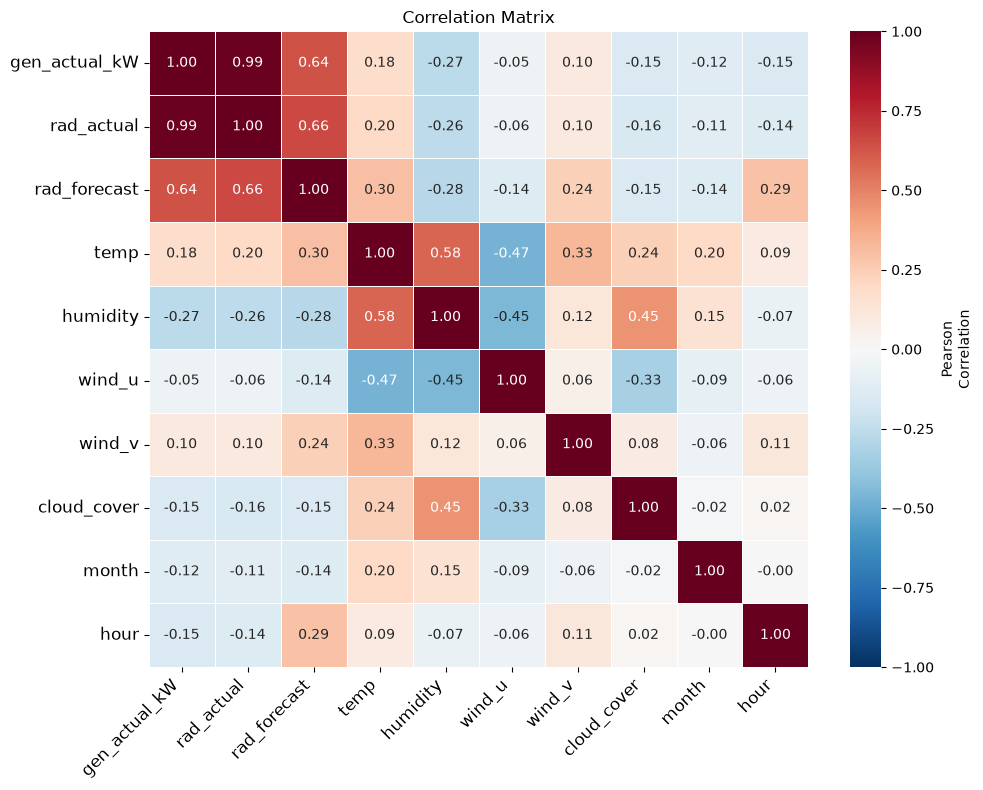

In [9]:
# Select only numeric columns for the correlation matrix
df_numeric = df.select_dtypes(include=[np.number])

# Correlation matrix: rounded to 2 decimals
corr = df_numeric.corr(method='pearson').round(2)

# Plotting the correlation matrix with numbers
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
                      vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'label': 'Pearson\nCorrelation'})
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


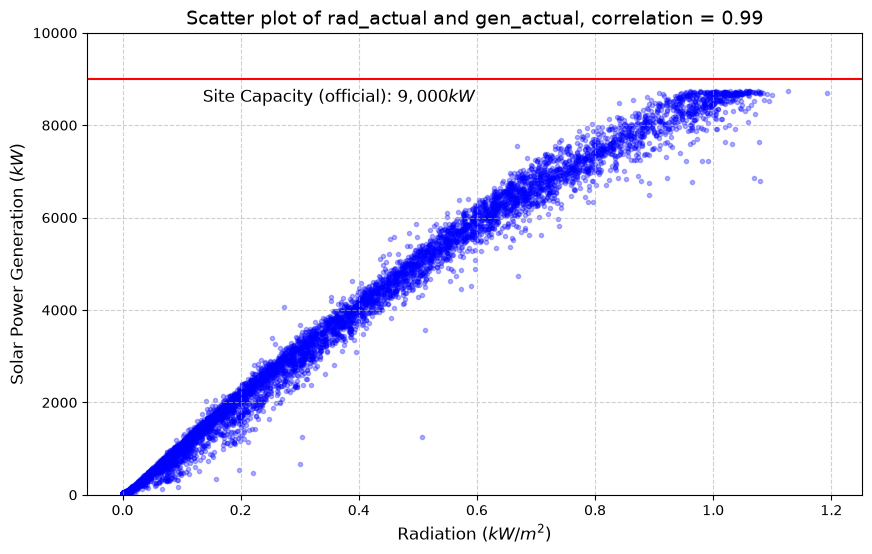

In [10]:
# Calculate the correlation between "rad_actual" and "gen_actual_kW", rounded to 2 decimals
corr_rad_gen = df['rad_actual'].corr(df['gen_actual_kW']).round(2)

# Scatter plot of "rad_actual" and "gen_actual_kW"
plt.figure(figsize=(10, 6))
plt.scatter(df['rad_actual'], df['gen_actual_kW'], color='blue', marker='.', alpha=0.3)
plt.axhline(y=9000, color='red', linestyle='-')
plt.text(df['rad_actual'].max() * 0.5, 8500, "Site Capacity (official): $9,000 kW$", color='black', ha='right', fontsize = 12) # Add text below the red line
plt.title(f"Scatter plot of rad_actual and gen_actual, correlation = 0.99", fontsize = 14)
plt.xlabel("Radiation ($kW/m^2$)", fontsize = 12)
plt.ylabel("Solar Power Generation ($kW$)", fontsize = 12)
plt.ylim(0, 10000)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Note: This solar power generation system boasts a maximum capacity of 8,000 kW, capping its output around this value. For broader applicability across diverse locations of solar power generation sites, we prioritize predicting actual radiation over generated solar power.

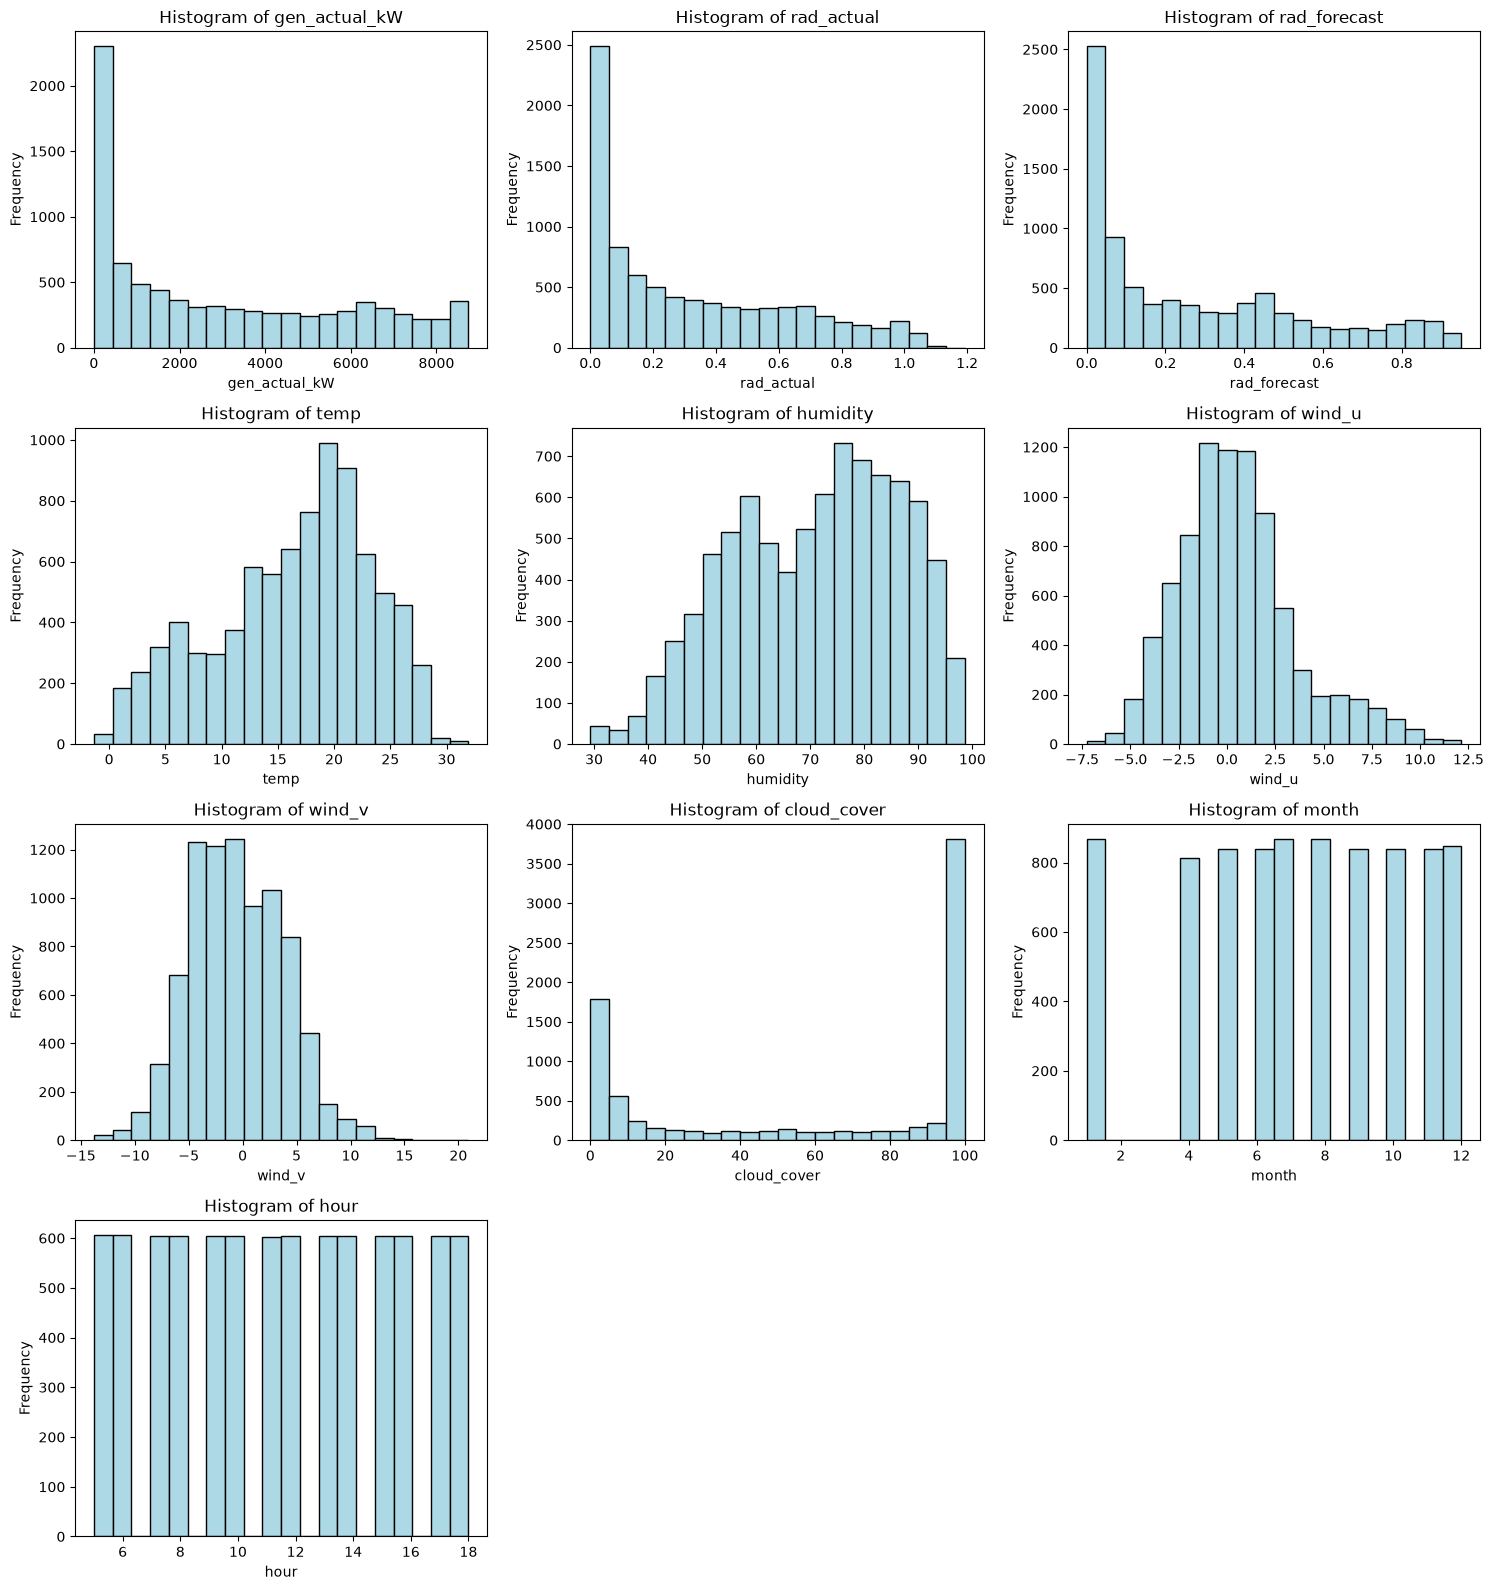

In [11]:
# Select numeric columns
hist_data = df.select_dtypes(include=[np.number])

# Set up the plot grid (adjust rows/cols as needed)
num_plots = len(hist_data.columns)
n_cols = 3
n_rows = int(np.ceil(num_plots / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

# Plot histograms
for i, col in enumerate(hist_data.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(hist_data[col].dropna(), bins=20, color='lightblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


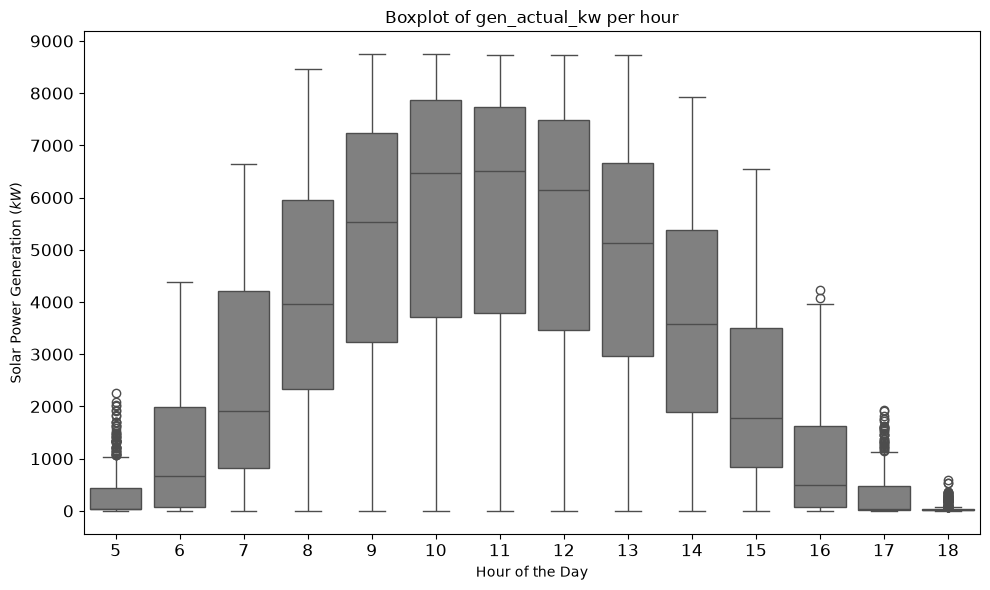

In [12]:
# Boxplot of gen_actual_kw per hour to check its volatility
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='hour',
    y='gen_actual_kW',
    color='gray',
    data = df)

# Set axis labels and title
plt.title("Boxplot of gen_actual_kw per hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Solar Power Generation ($kW$)")

# Set y-axis ticks in increments of 1000, up to max value
max_val = df['gen_actual_kW'].max(skipna=True)
plt.yticks(np.arange(0, max_val + 1000, 1000))

# Customize axis text
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

plt.tight_layout()
plt.show()



# Step 2. Prediction

Note: Moving forward, we'll work with two CSV files, `df_train.csv` and `df_test.csv`, previously split randomly at an 80/20 ratio. This setup allows us to assess the model's out-of-sample accuracy, a crucial metric for gauging its predictive robustness.

In [13]:
# Load the datasets
df_train = pd.read_csv('df_train.csv')
df_test = pd.read_csv('df_test.csv')

# Assuming df_full is already loaded or defined earlier
# Otherwise, load it as: df = pd.read_csv('df_full.csv')

# Checking the number of rows
print("df_train shape:", df_train.shape)
print("df_test shape:", df_test.shape)
print("df shape:", df.shape)

# Compare total rows
print("Checking the total number:", len(df_train) + len(df_test) == len(df))

df_train shape: (6768, 11)
df_test shape: (1693, 11)
df shape: (8461, 11)
Checking the total number: True


In [14]:
display(df_train.head())
display(df_test.head())

,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
0,2021-12-01 13:00:00,5685.0,0.5709,0.06588,11.520532,68.000000,6.944795,-4.159453,100.000000,12,13
1,2021-08-12 16:00:00,1690.0,0.1609,0.38670,23.778436,89.599998,-2.603098,-5.714180,59.000000,8,16
2,2021-08-23 06:30:00,19.0,0.0043,0.00419,22.476724,94.150002,-1.087933,-0.141467,100.000000,8,6
3,2021-05-28 12:30:00,7389.0,0.7959,0.88114,19.204614,74.600002,-0.754155,4.372010,98.400002,5,12
4,2021-05-22 11:00:00,3387.0,0.2956,0.07172,14.941034,97.000000,-3.121091,-4.730132,100.000000,5,11


,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
0,2021-11-28 13:00:00,6090.0,0.6455,0.487940,11.035242,44.400002,3.770229,-4.263638,44.799999,11,13
1,2021-11-27 16:00:00,103.0,0.0097,0.096960,8.292383,53.900002,6.399645,-5.937185,0.500000,11,16
2,2021-04-24 09:30:00,8099.0,0.8853,0.514148,13.456201,58.600000,-0.914987,-0.391671,88.549999,4,9
3,2021-09-27 07:00:00,1245.0,0.1184,0.036896,18.508966,76.400002,-0.321240,-3.044473,9.200000,9,7
4,2021-05-01 13:00:00,3002.0,0.3033,0.839264,16.350000,58.700001,-3.870542,0.665400,100.000000,5,13


In [15]:
# Show the first 5 rows of the train dataset
df_train.head(5)

,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
0,2021-12-01 13:00:00,5685.0,0.5709,0.06588,11.520532,68.000000,6.944795,-4.159453,100.000000,12,13
1,2021-08-12 16:00:00,1690.0,0.1609,0.38670,23.778436,89.599998,-2.603098,-5.714180,59.000000,8,16
2,2021-08-23 06:30:00,19.0,0.0043,0.00419,22.476724,94.150002,-1.087933,-0.141467,100.000000,8,6
3,2021-05-28 12:30:00,7389.0,0.7959,0.88114,19.204614,74.600002,-0.754155,4.372010,98.400002,5,12
4,2021-05-22 11:00:00,3387.0,0.2956,0.07172,14.941034,97.000000,-3.121091,-4.730132,100.000000,5,11


In [16]:
# Summary including all columns (numeric + non-numeric)
df_train.describe()

,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
count,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000,6768.000000
mean,3013.089096,0.316141,0.272951,16.425757,70.955832,0.554329,-0.457666,59.584416,7.329787,11.478132
std,2815.603535,0.308330,0.274759,6.954365,15.329245,3.076459,4.343543,43.067045,3.220481,4.039570
min,0.000000,0.000000,0.000000,-1.357672,29.300001,-7.259287,-13.785872,0.000000,1.000000,5.000000
25%,328.750000,0.037575,0.033745,11.906454,58.400002,-1.444064,-3.715251,5.787500,5.000000,8.000000
50%,2160.000000,0.213400,0.174556,17.711725,72.800003,0.214175,-0.679368,83.049999,8.000000,11.000000
75%,5521.500000,0.556450,0.456816,21.517706,83.562502,2.049486,2.786647,100.000000,10.000000,15.000000
max,8747.000000,1.192700,0.950912,31.950006,98.450001,12.129041,20.932898,100.000000,12.000000,18.000000


In [17]:
# Show the first 5 rows of the test dataset
df_test.head(5)

,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
0,2021-11-28 13:00:00,6090.0,0.6455,0.487940,11.035242,44.400002,3.770229,-4.263638,44.799999,11,13
1,2021-11-27 16:00:00,103.0,0.0097,0.096960,8.292383,53.900002,6.399645,-5.937185,0.500000,11,16
2,2021-04-24 09:30:00,8099.0,0.8853,0.514148,13.456201,58.600000,-0.914987,-0.391671,88.549999,4,9
3,2021-09-27 07:00:00,1245.0,0.1184,0.036896,18.508966,76.400002,-0.321240,-3.044473,9.200000,9,7
4,2021-05-01 13:00:00,3002.0,0.3033,0.839264,16.350000,58.700001,-3.870542,0.665400,100.000000,5,13


In [18]:
# Show the summary statistics of the numerical columns of the test dataset
df_test.describe()

,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,hour
count,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000,1693.000000
mean,2988.803308,0.314648,0.275746,16.073943,70.740476,0.504822,-0.779638,61.283162,7.155346,11.574719
std,2801.333685,0.309945,0.276219,6.985855,15.492101,3.087387,4.335103,42.417524,3.278101,4.007956
min,0.000000,0.000000,0.000000,-1.290518,30.000000,-6.189180,-12.795044,0.000000,1.000000,5.000000
25%,319.000000,0.036000,0.036240,11.649042,58.299999,-1.658314,-3.998586,7.800000,5.000000,8.000000
50%,2179.000000,0.213900,0.180320,17.260248,73.099998,0.160142,-1.210037,86.950001,7.000000,12.000000
75%,5321.000000,0.537400,0.459020,21.086633,83.200005,2.053100,2.561956,100.000000,10.000000,15.000000
max,8741.000000,1.127000,0.945820,31.339655,98.599998,12.128586,13.939809,100.000000,12.000000,18.000000


In [19]:
# Create an empty DataFrame to store performance metrics later
performance_metrics = pd.DataFrame(columns=[
    'Model', 'Train_R2', 'Test_R2', 'Test_MAE', 'Test_RMSE'
])

## 2.1 Single Linear Regression

Relationship between forecast and Actual Radiation

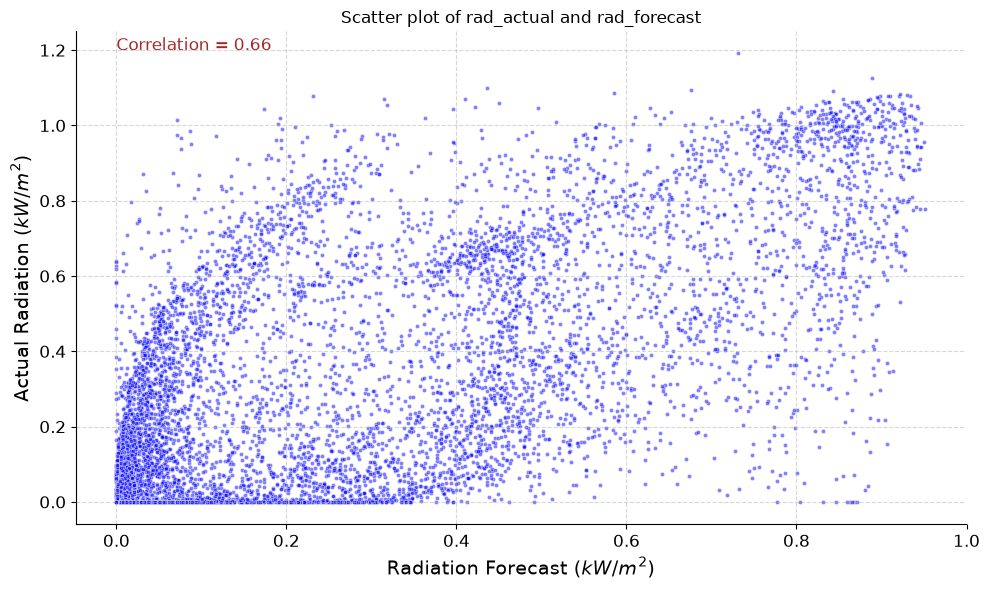

In [20]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='rad_forecast', y='rad_actual', color='blue', marker = '.', alpha=0.5)

plt.title("Scatter plot of rad_actual and rad_forecast", fontsize=12)
plt.xlabel("Radiation Forecast ($kW/m^2$)", fontsize=14, color='black')
plt.ylabel("Actual Radiation ($kW/m^2$)", fontsize=14, color='black')
corr = df['rad_forecast'].corr(df['rad_actual'])
plt.text(0, 1.2, f"Correlation = {corr:.2f}", ha='left', fontsize=12, color='brown')

# Axis styling
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')

# Axis limits (max 1.25)
plt.xlim(None, 1)
plt.ylim(None, 1.25)

# Apply minimal theme (similar to theme_minimal)
sns.despine()

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


Prediction based on radiation forecast

In [21]:
# Fit the linear regression model using statsmodels
model = smf.ols('rad_actual ~ rad_forecast', data=df_train).fit()

# Print the model summary using the custom function
print_summary_with_stars(model)
print()

               Coef.  Std.Err.        t  P>|t|  [0.025  0.975] Signif
---------------------------------------------------------------------
Intercept     0.1122    0.0039  28.4643    0.0  0.1045  0.1199    ***
rad_forecast  0.7471    0.0102  73.3944    0.0  0.7272  0.7671    ***
R-squared: 0.4433



In [22]:
# Predict on the test set
df_test['pred_single'] = model.predict(df_test)

# Using statsmodels rsquared for train
r2_train = model.rsquared
r2_test = r2_score(df_test['rad_actual'], df_test['pred_single'])
rmse_test = mean_squared_error(df_test['rad_actual'], df_test['pred_single'])**0.5
mae_test = mean_absolute_error(df_test['rad_actual'], df_test['pred_single'])

# Print the metrics
print(f'Single Model - R-Squared of train: {r2_train:.2f}')
print(f'Single Model - R-Squared of test: {r2_test:.2f}')
print(f'Single Model - RMSE of test: {rmse_test:.2f}')
print(f'Single Model - MAE of test: {mae_test:.2f}')

# Store the metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Single Model',
        'Train_R2': r2_train,
        'Test_R2': r2_test,
        'Test_MAE': mae_test,
        'Test_RMSE': rmse_test
    }])
], ignore_index=True)

Single Model - R-Squared of train: 0.44
Single Model - R-Squared of test: 0.43
Single Model - RMSE of test: 0.23
Single Model - MAE of test: 0.19


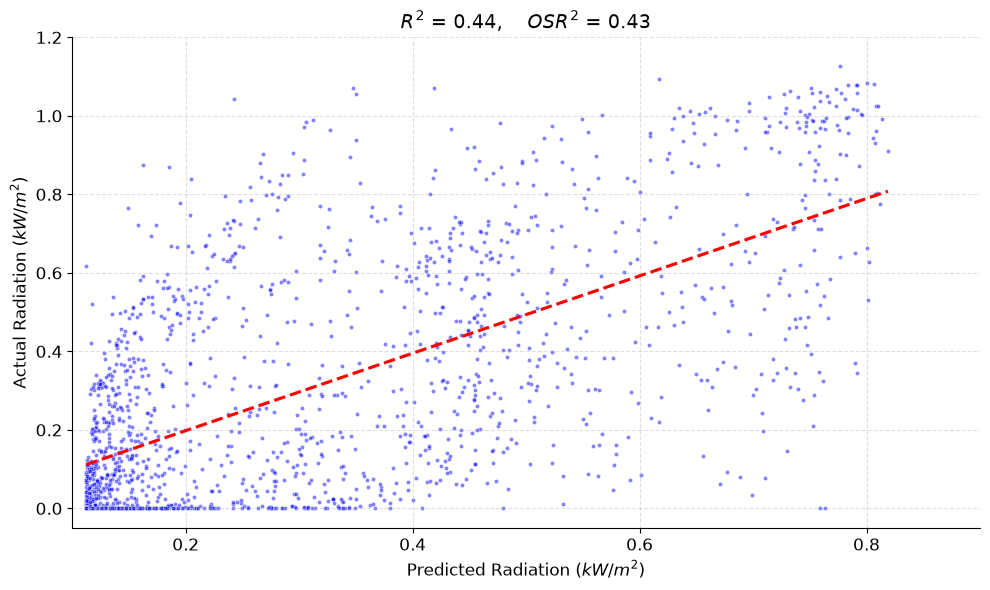

In [23]:
# Create the scatter plot with the regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test, x='pred_single', y='rad_actual', color='blue', marker='.', alpha=0.5)
sns.regplot(data=df_test, x='pred_single', y='rad_actual',
            scatter=False, color='red', ci=None, line_kws={'linestyle': '--'})

# Set axis limits and breaks
plt.xticks(np.arange(0, 1.21, 0.2), fontsize=12, color="black")
plt.yticks(np.arange(0, 1.21, 0.2), fontsize=12, color="black")

# Set titles and labels
plt.title(f'$R^2$ = {model.rsquared:.2f},    $OSR^2$ = {r2_test:.2f}', fontsize=14)
plt.xlabel('Predicted Radiation ($kW/m^2$)', fontsize=12, color="black")
plt.ylabel('Actual Radiation ($kW/m^2$)', fontsize=12, color="black")

# Axis limits (max 1.25)
plt.xlim(0.1, 0.9)
plt.ylim(-0.05, 1.2)

# Apply a minimal theme (removes top and right borders)
sns.despine()

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 2.2 Multiple Linear Regression: 6 Different Models


| Model   | Description                                                                                         |
|---------|-----------------------------------------------------------------------------------------------------|
| Model 0 | Includes ‘rad_forecast’, ‘temp’, ‘humidity’, ‘wind_u’, ‘wind_v’, ‘cloud_cover’, ‘month’, and ‘hour’ |
| Model 1 | Includes ‘rad_forecast’, ‘temp’, ‘humidity’, ‘wind_u’, ‘wind_v’, ‘cloud_cover’                      |
| Model 2 | Model 1 + Month: Adds ‘month’ as a continuous variable to the basic model                           |
| Model 3 | Model 1 + Categorical Month: Adds ‘month’ as categorical (dummy variables) to the basic model       |
| Model 4 | Model 1 + Hours: Adds ‘hour’ as a continuous variable to the basic model                            |
| Model 5 | Model 1 + Categorical Hours: Adds ‘hour’ as categorical (dummy variables) to the basic model        |
| Model 6 | Model 1 + Categorical Month + Categorical Hours: Combines the basic model with both categorical months and hours |


### 2.2.1 Model 0

In [24]:
# Fit the multiple linear regression model using statsmodels
model0 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + month + hour',
    data=df_train
).fit()

# Predict on the test set
df_test['pred0'] = model0.predict(df_test)

# Calculate metrics
r2_test0 = r2_score(df_test['rad_actual'], df_test['pred0'])
rmse_test0 = mean_squared_error(df_test['rad_actual'], df_test['pred0'])**0.5
mae_test0 = mean_absolute_error(df_test['rad_actual'], df_test['pred0'])

# Print summary and metrics
print_summary_with_stars(model0)
print()

print(f'Model 0 - R-Squared of train: {model0.rsquared:.2f}')
print(f'Model 0 - R-Squared of test: {r2_test0:.2f}')
print(f'Model 0 - RMSE of test: {rmse_test0:.2f}')
print(f'Model 0 - MAE of test: {mae_test0:.2f}')

# Store the metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 0',
        'Train_R2': model0.rsquared,
        'Test_R2': r2_test0,
        'Test_RMSE': rmse_test0,
        'Test_MAE': mae_test0
    }])
], ignore_index=True)

               Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
----------------------------------------------------------------------
Intercept     0.5223    0.0190  27.4566  0.0000  0.4850  0.5596    ***
rad_forecast  0.7842    0.0126  62.3704  0.0000  0.7596  0.8089    ***
temp          0.0064    0.0006  11.2964  0.0000  0.0053  0.0075    ***
humidity     -0.0030    0.0003 -11.2078  0.0000 -0.0035 -0.0024    ***
wind_u        0.0026    0.0010   2.6244  0.0087  0.0007  0.0046     **
wind_v       -0.0041    0.0006  -6.5215  0.0000 -0.0054 -0.0029    ***
cloud_cover   0.0000    0.0001   0.0883  0.9297 -0.0001  0.0001       
month        -0.0016    0.0008  -1.9668  0.0492 -0.0032 -0.0000      *
hour         -0.0268    0.0006 -42.1308  0.0000 -0.0281 -0.0256    ***
R-squared: 0.5736

Model 0 - R-Squared of train: 0.57
Model 0 - R-Squared of test: 0.56
Model 0 - RMSE of test: 0.20
Model 0 - MAE of test: 0.16


### 2.2.1 Model 1: Basic Model

In [25]:
# Fit Model 1 with selected predictors
model1 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover',
    data=df_train
).fit()

# Predict on test set
df_test['pred1'] = model1.predict(df_test)

# Calculate metrics
r2_test1 = r2_score(df_test['rad_actual'], df_test['pred1'])
rmse_test1 = mean_squared_error(df_test['rad_actual'], df_test['pred1'])**0.5
mae_test1 = mean_absolute_error(df_test['rad_actual'], df_test['pred1'])

# Print model summary and metrics
print_summary_with_stars(model1)
print()
print(f'Model 1 - R-Squared of train: {model1.rsquared:.2f}')
print(f'Model 1 - R-Squared of test: {r2_test1:.2f}')
print(f'Model 1 - RMSE of test: {rmse_test1:.2f}')
print(f'Model 1 - MAE of test: {mae_test1:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 1',
        'Train_R2': model1.rsquared,
        'Test_R2': r2_test1,
        'Test_RMSE': rmse_test1,
        'Test_MAE': mae_test1
    }])
], ignore_index=True)

               Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
----------------------------------------------------------------------
Intercept     0.2262    0.0190  11.8902  0.0000  0.1889  0.2635    ***
rad_forecast  0.6757    0.0134  50.2956  0.0000  0.6494  0.7021    ***
temp          0.0065    0.0006  10.5609  0.0000  0.0053  0.0078    ***
humidity     -0.0028    0.0003  -9.3973  0.0000 -0.0034 -0.0022    ***
wind_u        0.0033    0.0011   2.8961  0.0038  0.0011  0.0055     **
wind_v       -0.0053    0.0007  -7.4790  0.0000 -0.0067 -0.0039    ***
cloud_cover  -0.0002    0.0001  -2.0723  0.0383 -0.0003 -0.0000      *
R-squared: 0.4602

Model 1 - R-Squared of train: 0.46
Model 1 - R-Squared of test: 0.45
Model 1 - RMSE of test: 0.23
Model 1 - MAE of test: 0.19


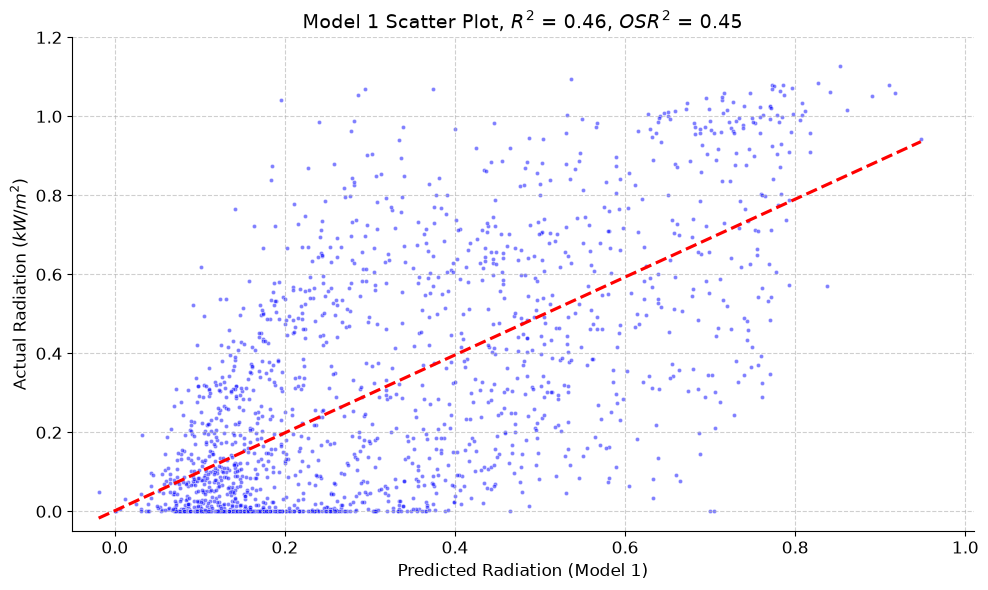

In [26]:
# Create the scatter plot with the regression line for Model 1
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test, x='pred1', y='rad_actual', color='blue', marker='.', alpha=0.5)
sns.regplot(data=df_test, x='pred1', y='rad_actual',
            scatter=False, color='red', ci=None, line_kws={'linestyle': '--'})

# Set axis limits and breaks (adjust as needed for your data range)
plt.xlim(-0.05, 1.01)
plt.ylim(-0.05, 1.2)
plt.xticks(np.arange(0, 1.01, 0.2), fontsize=12, color='black')
plt.yticks(np.arange(0, 1.21, 0.2), fontsize=12, color='black')

# Set titles and labels
plt.title(f'Model 1 Scatter Plot, $R^2$ = {model1.rsquared:.2f}, $OSR^2$ = {r2_test1:.2f}', fontsize=14)
plt.xlabel('Predicted Radiation (Model 1)', fontsize=12, color="black")
plt.ylabel('Actual Radiation ($kW/m^2$)', fontsize=12, color="black")

plt.grid(True, linestyle='--', alpha=0.6)

# Apply a minimal theme (removes top and right borders)
sns.despine()
plt.tight_layout()
plt.show()

### 2.2.2 Model 2: Basic Model + Month as Continuous

In [27]:
# Fit Model 2 with selected predictors (excluding hour)
model2 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + month',
    data=df_train
).fit()

# Predict on test set
df_test['pred2'] = model2.predict(df_test)

# Calculate metrics
r2_test2 = r2_score(df_test['rad_actual'], df_test['pred2'])
rmse_test2 = mean_squared_error(df_test['rad_actual'], df_test['pred2'])**0.5
mae_test2 = mean_absolute_error(df_test['rad_actual'], df_test['pred2'])

# Print model summary and metrics
print_summary_with_stars(model2)
print()
print(f'Model 2 - R-Squared of train: {model2.rsquared:.2f}')
print(f'Model 2 - R-Squared of test: {r2_test2:.2f}')
print(f'Model 2 - RMSE of test: {rmse_test2:.2f}')
print(f'Model 2 - MAE of test: {mae_test2:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 2',
        'Train_R2': model2.rsquared,
        'Test_R2': r2_test2,
        'Test_RMSE': rmse_test2,
        'Test_MAE': mae_test2
    }])
], ignore_index=True)

               Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
----------------------------------------------------------------------
Intercept     0.2545    0.0201  12.6324  0.0000  0.2150  0.2939    ***
rad_forecast  0.6630    0.0138  48.2097  0.0000  0.6360  0.6900    ***
temp          0.0072    0.0006  11.2869  0.0000  0.0060  0.0085    ***
humidity     -0.0029    0.0003  -9.6615  0.0000 -0.0034 -0.0023    ***
wind_u        0.0032    0.0011   2.7905  0.0053  0.0009  0.0054     **
wind_v       -0.0056    0.0007  -7.8088  0.0000 -0.0070 -0.0042    ***
cloud_cover  -0.0002    0.0001  -2.5022  0.0124 -0.0003 -0.0000      *
month        -0.0038    0.0009  -4.2249  0.0000 -0.0056 -0.0020    ***
R-squared: 0.4616

Model 2 - R-Squared of train: 0.46
Model 2 - R-Squared of test: 0.45
Model 2 - RMSE of test: 0.23
Model 2 - MAE of test: 0.19


### 2.2.3 Model 3: Basic Model + Categorical Month

In [28]:
# Fit Model 3 with selected predictors and categorical month
# statsmodels handles categorical variables when specified in the formula
model3 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + C(month)',
    data=df_train
).fit()

# Predict on test set
df_test['pred3'] = model3.predict(df_test)

# Calculate metrics
r2_test3 = r2_score(df_test['rad_actual'], df_test['pred3'])
rmse_test3 = mean_squared_error(df_test['rad_actual'], df_test['pred3'])**0.5
mae_test3 = mean_absolute_error(df_test['rad_actual'], df_test['pred3'])

# Print model summary and metrics
print_summary_with_stars(model3)
print()
print(f'Model 3 - R-Squared of train: {model3.rsquared:.2f}')
print(f'Model 3 - R-Squared of test: {r2_test3:.2f}')
print(f'Model 3 - RMSE of test: {rmse_test3:.2f}')
print(f'Model 3 - MAE of test: {mae_test3:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 3',
        'Train_R2': model3.rsquared,
        'Test_R2': r2_test3,
        'Test_RMSE': rmse_test3,
        'Test_MAE': mae_test3
    }])
], ignore_index=True)

                 Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
------------------------------------------------------------------------
Intercept       0.2890    0.0225  12.8476  0.0000  0.2449  0.3330    ***
C(month)[T.4]   0.0420    0.0156   2.6860  0.0072  0.0113  0.0726     **
C(month)[T.5]   0.0739    0.0188   3.9222  0.0001  0.0369  0.1108    ***
C(month)[T.6]   0.1318    0.0216   6.1108  0.0000  0.0895  0.1740    ***
C(month)[T.7]   0.0724    0.0259   2.7975  0.0052  0.0217  0.1231     **
C(month)[T.8]   0.0620    0.0271   2.2860  0.0223  0.0088  0.1152      *
C(month)[T.9]   0.0311    0.0235   1.3211  0.1865 -0.0150  0.0771       
C(month)[T.10]  0.0302    0.0199   1.5192  0.1288 -0.0088  0.0692       
C(month)[T.11]  0.0056    0.0164   0.3390  0.7346 -0.0266  0.0377       
C(month)[T.12]  0.0069    0.0129   0.5325  0.5944 -0.0184  0.0321       
rad_forecast    0.6409    0.0144  44.6552  0.0000  0.6127  0.6690    ***
temp            0.0050    0.0013   3.9843  0.0001  

### 2.2.4 Model 4: Basic Model + Hours as Continuous

In [29]:
model4 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + hour',
    data=df_train
).fit()

# Predict on test set
df_test['pred4'] = model4.predict(df_test)

# Calculate metrics
r2_test4 = r2_score(df_test['rad_actual'], df_test['pred4'])
rmse_test4 = mean_squared_error(df_test['rad_actual'], df_test['pred4'])**0.5
mae_test4 = mean_absolute_error(df_test['rad_actual'], df_test['pred4'])

# Print model summary and metrics
print_summary_with_stars(model4)
print()
print(f'Model 3 - R-Squared of train: {model4.rsquared:.2f}')
print(f'Model 3 - R-Squared of test: {r2_test4:.2f}')
print(f'Model 3 - RMSE of test: {rmse_test4:.2f}')
print(f'Model 3 - MAE of test: {mae_test4:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 4',
        'Train_R2': model4.rsquared,
        'Test_R2': r2_test4,
        'Test_RMSE': rmse_test4,
        'Test_MAE': mae_test4
    }])
], ignore_index=True)

               Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
----------------------------------------------------------------------
Intercept     0.5114    0.0182  28.0869  0.0000  0.4757  0.5471    ***
rad_forecast  0.7898    0.0122  64.5013  0.0000  0.7658  0.8139    ***
temp          0.0061    0.0006  11.1535  0.0000  0.0051  0.0072    ***
humidity     -0.0029    0.0003 -11.1027  0.0000 -0.0034 -0.0024    ***
wind_u        0.0027    0.0010   2.6733  0.0075  0.0007  0.0047     **
wind_v       -0.0040    0.0006  -6.3760  0.0000 -0.0053 -0.0028    ***
cloud_cover   0.0000    0.0001   0.3021  0.7626 -0.0001  0.0001       
hour         -0.0269    0.0006 -42.3427  0.0000 -0.0282 -0.0257    ***
R-squared: 0.5733

Model 3 - R-Squared of train: 0.57
Model 3 - R-Squared of test: 0.56
Model 3 - RMSE of test: 0.20
Model 3 - MAE of test: 0.16


### 2.2.5 Model 5: Basic Model + Categorical Hours

In [30]:
model5 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + C(hour)',
    data=df_train
).fit()

# Predict on test set
# Make sure 'hour' column is present in df_test, which it should be if it was created similarly to df_train
df_test['pred5'] = model5.predict(df_test)

# Calculate metrics
r2_test5 = r2_score(df_test['rad_actual'], df_test['pred5'])
rmse_test5 = mean_squared_error(df_test['rad_actual'], df_test['pred5'])**0.5
mae_test5 = mean_absolute_error(df_test['rad_actual'], df_test['pred5'])

# Print model summary and metrics
print_summary_with_stars(model5)
print()
print(f'Model 5 - R-Squared of train: {model5.rsquared:.2f}')
print(f'Model 5 - R-Squared of test: {r2_test5:.2f}')
print(f'Model 5 - RMSE of test: {rmse_test5:.2f}')
print(f'Model 5 - MAE of test: {mae_test5:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 5',
        'Train_R2': model5.rsquared,
        'Test_R2': r2_test5,
        'Test_RMSE': rmse_test5,
        'Test_MAE': mae_test5
    }])
], ignore_index=True)

                Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
-----------------------------------------------------------------------
Intercept      0.1150    0.0156   7.3719  0.0000  0.0844  0.1456    ***
C(hour)[T.6]   0.0720    0.0104   6.9528  0.0000  0.0517  0.0923    ***
C(hour)[T.7]   0.1932    0.0104  18.5994  0.0000  0.1729  0.2136    ***
C(hour)[T.8]   0.3097    0.0105  29.6294  0.0000  0.2892  0.3302    ***
C(hour)[T.9]   0.3737    0.0108  34.7386  0.0000  0.3526  0.3948    ***
C(hour)[T.10]  0.2947    0.0117  25.2584  0.0000  0.2719  0.3176    ***
C(hour)[T.11]  0.2769    0.0119  23.3450  0.0000  0.2537  0.3002    ***
C(hour)[T.12]  0.2302    0.0119  19.3009  0.0000  0.2068  0.2535    ***
C(hour)[T.13]  0.1668    0.0120  13.8755  0.0000  0.1432  0.1904    ***
C(hour)[T.14]  0.0462    0.0119   3.8909  0.0001  0.0229  0.0695    ***
C(hour)[T.15] -0.0556    0.0114  -4.8662  0.0000 -0.0781 -0.0332    ***
C(hour)[T.16] -0.0717    0.0107  -6.6881  0.0000 -0.0927 -0.0507

### 2.2.6 Model 6: Basic Model + Categorical Month + Categorical Hours

In [31]:
model6 = smf.ols(
    'rad_actual ~ rad_forecast + temp + humidity + wind_u + wind_v + cloud_cover + C(month) + C(hour)',
    data=df_train
).fit()

# Predict on test set
df_test['pred6'] = model6.predict(df_test)

# Calculate metrics
r2_test6 = r2_score(df_test['rad_actual'], df_test['pred6'])
rmse_test6 = mean_squared_error(df_test['rad_actual'], df_test['pred6'])**0.5
mae_test6 = mean_absolute_error(df_test['rad_actual'], df_test['pred6'])

# Print model summary and metrics
print_summary_with_stars(model6)
print()
print(f'Model 6 - R-Squared of train: {model6.rsquared:.2f}')
print(f'Model 6 - R-Squared of test: {r2_test6:.2f}')
print(f'Model 6 - RMSE of test: {rmse_test6:.2f}')
print(f'Model 6 - MAE of test: {mae_test6:.2f}')

# Store metrics
performance_metrics = pd.concat([
    performance_metrics,
    pd.DataFrame([{
        'Model': 'Model 6',
        'Train_R2': model6.rsquared,
        'Test_R2': r2_test6,
        'Test_RMSE': rmse_test6,
        'Test_MAE': mae_test6
    }])
], ignore_index=True)

                 Coef.  Std.Err.        t   P>|t|  [0.025  0.975] Signif
------------------------------------------------------------------------
Intercept       0.1744    0.0175   9.9573  0.0000  0.1401  0.2088    ***
C(month)[T.4]   0.0566    0.0113   5.0336  0.0000  0.0346  0.0787    ***
C(month)[T.5]   0.0663    0.0136   4.8852  0.0000  0.0397  0.0930    ***
C(month)[T.6]   0.1236    0.0156   7.9376  0.0000  0.0930  0.1541    ***
C(month)[T.7]   0.0538    0.0186   2.8950  0.0038  0.0174  0.0903     **
C(month)[T.8]   0.0295    0.0194   1.5196  0.1287 -0.0086  0.0676       
C(month)[T.9]   0.0105    0.0168   0.6245  0.5323 -0.0224  0.0434       
C(month)[T.10]  0.0010    0.0142   0.0711  0.9433 -0.0267  0.0287       
C(month)[T.11] -0.0195    0.0117  -1.6701  0.0949 -0.0423  0.0034      .
C(month)[T.12] -0.0110    0.0091  -1.2076  0.2273 -0.0289  0.0069       
C(hour)[T.6]    0.0729    0.0101   7.1894  0.0000  0.0530  0.0928    ***
C(hour)[T.7]    0.1961    0.0102  19.2607  0.0000  

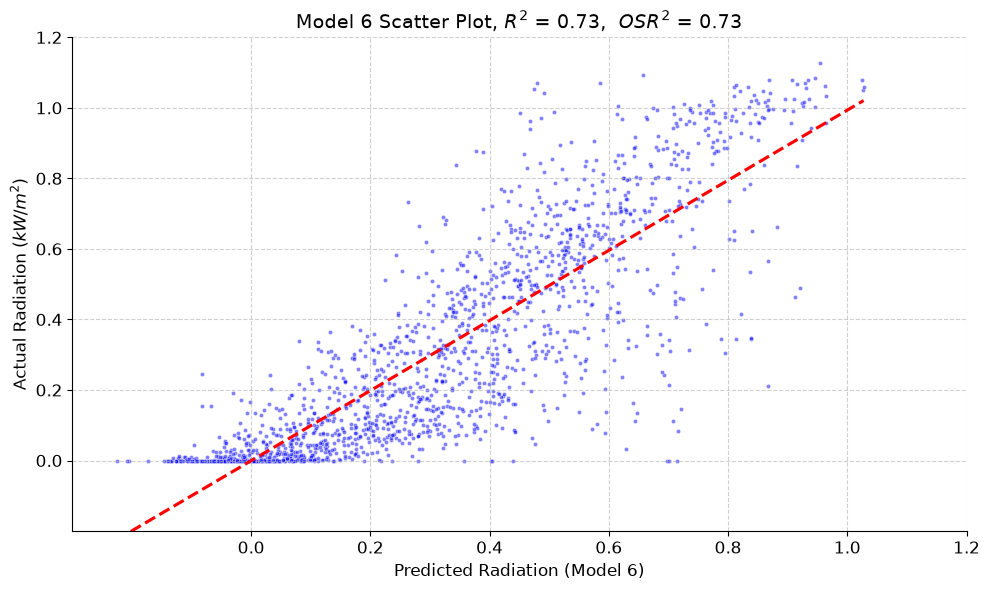

In [32]:
# Create the scatter plot with the regression line for Model 6
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test, x='pred6', y='rad_actual', color='blue', marker='.', alpha=0.5)
sns.regplot(data=df_test, x='pred6', y='rad_actual',
            scatter=False, color='red', ci=None, line_kws={'linestyle': '--'})


# Set axis limits and breaks
plt.xlim(-0.3, 1.2)
plt.ylim(-0.2, 1.2)
plt.xticks(np.arange(0, 1.21, 0.2), fontsize=12, color="black")
plt.yticks(np.arange(0, 1.21, 0.2), fontsize=12, color="black")

# Set titles and labels
plt.title(f'Model 6 Scatter Plot, $R^2$ = {model6.rsquared:.2f},  $OSR^2$ = {r2_test6:.2f}', fontsize=14)
plt.xlabel('Predicted Radiation (Model 6)', fontsize=12, color="black")
plt.ylabel('Actual Radiation ($kW/m^2$)', fontsize=12, color="black")

# Apply a minimal theme (removes top and right borders)
sns.despine()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Note: Feature Engineering: Transforming ‘Hour’ to Categorical for Improved Model Performance

When analyzing the impact of the ‘hour’ variable on the target variable (e.g., ‘rad_actual’), it was observed that the relationship is not linear. This non-linear relationship implies that a linear regression model, which inherently assumes linearity, would struggle to accurately capture the trend between ‘hour’ and ‘rad_actual’ using a single positive or negative coefficient.

To address this, transforming the ‘hour’ variable into a categorical variable was found to significantly enhance the model’s performance. This transformation effectively allows the model to handle the unique impact of each hour as a separate category, rather than trying to fit these variations into a linear framework. This kind of data manipulation is a classic example of feature engineering, a crucial step in model building.

Feature engineering requires creativity and domain knowledge. It involves transforming or creating variables to better represent the underlying phenomena that the model aims to capture, thereby improving the model’s accuracy and predictive power.

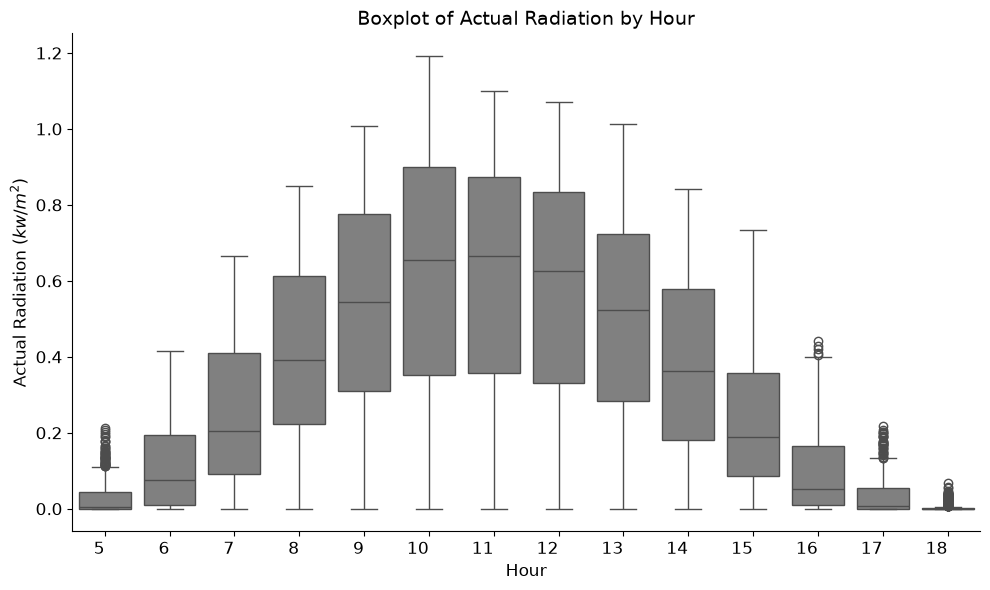

In [33]:
# Ensure 'hour' is treated as a categorical variable (important for seaborn boxplot)
df['hour'] = df['hour'].astype(str)

# Create the boxplot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hour', y='rad_actual', color='gray')

# Customize the plot similar to the R code
plt.xlabel('Hour', fontsize=12, color='black')
plt.ylabel('Actual Radiation ($kw/m^2$)', fontsize=12, color='black')
plt.xticks(fontsize=12, color='black', ha='right')
plt.yticks(fontsize=12, color='black')
plt.title('Boxplot of Actual Radiation by Hour', fontsize=14)

# Apply minimal theme (removes top and right borders)
sns.despine()
plt.tight_layout()
plt.show()

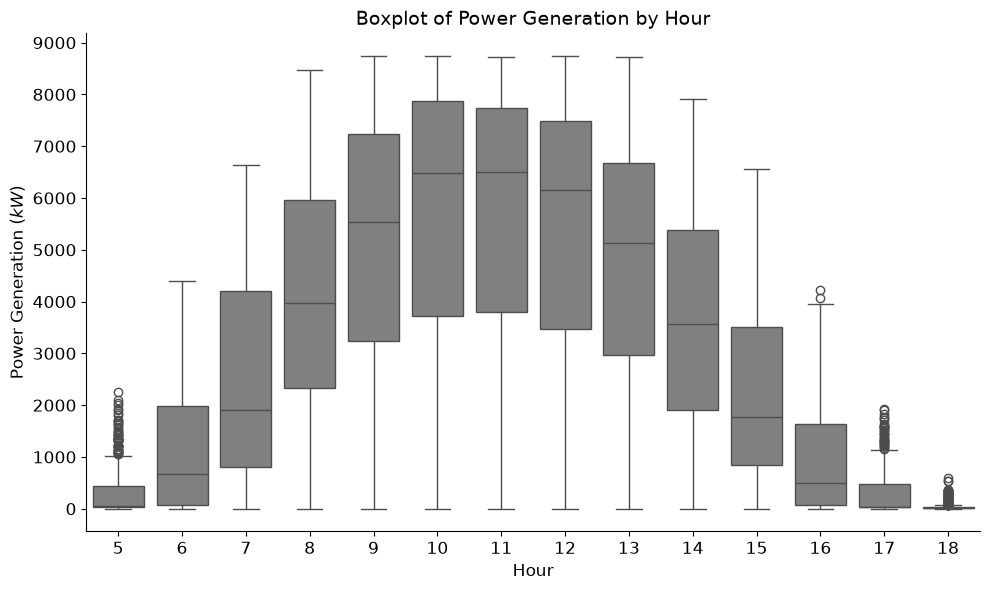

In [34]:
# Create the boxplot for y = gen_actual_kW
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='hour', y='gen_actual_kW', color='gray')

# Customize y-axis ticks: increments of 1000 up to the max
y_max = df['gen_actual_kW'].max(skipna=True)
plt.yticks(ticks=range(0, int(y_max) + 1000, 1000))

# Styling
plt.xlabel('Hour', fontsize=12, color='black')
plt.ylabel('Power Generation ($kW$)', fontsize=12, color='black')
plt.xticks(fontsize=12, color='black')
plt.yticks(fontsize=12, color='black')
plt.title('Boxplot of Power Generation by Hour', fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

## Models Summary

In [35]:
# Remove duplicate entries for each model, keeping the last one
performance_metrics_cleaned = performance_metrics.groupby('Model').tail(1).reset_index(drop=True)

# Define a custom order for the models
model_order = ['Single Model', 'Model 0', 'Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5', 'Model 6']

# Convert the 'Model' column to a categorical type with the custom order
performance_metrics_cleaned['Model'] = pd.Categorical(performance_metrics_cleaned['Model'], categories=model_order, ordered=True)

# Sort by the custom ordered 'Model' column
performance_metrics_cleaned = performance_metrics_cleaned.sort_values(by='Model').reset_index(drop=True)


# Round the numerical columns to 2 decimal places
performance_metrics_rounded = performance_metrics_cleaned.copy()
performance_metrics_rounded['Train_R2'] = performance_metrics_cleaned['Train_R2'].round(2)
performance_metrics_rounded['Test_R2'] = performance_metrics_cleaned['Test_R2'].round(2)
performance_metrics_rounded['Test_MAE'] = performance_metrics_cleaned['Test_MAE'].round(2)
performance_metrics_rounded['Test_RMSE'] = performance_metrics_cleaned['Test_RMSE'].round(2)

# Display the rounded performance metrics
performance_metrics_rounded

,Model,Train_R2,Test_R2,Test_MAE,Test_RMSE
0,Single Model,0.44,0.43,0.19,0.23
1,Model 0,0.57,0.56,0.16,0.2
2,Model 1,0.46,0.45,0.19,0.23
3,Model 2,0.46,0.45,0.19,0.23
4,Model 3,0.47,0.45,0.19,0.23
5,Model 4,0.57,0.56,0.16,0.2
6,Model 5,0.72,0.72,0.12,0.17
7,Model 6,0.73,0.73,0.12,0.16


# Step 3: Cost Impact

**Warning!**

The calculations presented here are intentionally simplified to facilitate understanding. In real-world scenarios, cost impact analyses can be significantly more intricate and dynamic, influenced by factors like demand, supply, and time intervals. Nevertheless, this simplified analysis offers a valuable introduction to the concept and highlights the significance of using AI modeling to estimate potential cost implications.

The provided Python code demonstrates how to compute the total propagated error and penalty by leveraging the RMSE from our predictive models and the coefficients from a basic regression model, which relates rad_actual to gen_actual (generation). It serves as a practical starting point for initial assessments and can be customized to explore various scenarios by adjusting parameters.

Considering the ever-changing nature of imbalance penalty costs over time, it’s important to recognize that more advanced modeling techniques may be necessary to capture these fluctuations accurately.

In [36]:
# Fit the model
model_solar = smf.ols('gen_actual_kW ~ rad_actual', data=df).fit()
print_summary_with_stars(model_solar)

# Store coefficient of rad_actual
coefficient_rad_actual = model_solar.params["rad_actual"]


                Coef.  Std.Err.         t  P>|t|     [0.025     0.975] Signif
-----------------------------------------------------------------------------
Intercept    150.0034    5.1551   29.0981    0.0   139.8982   160.1087    ***
rad_actual  9049.5389   11.6740  775.1906    0.0  9026.6551  9072.4227    ***
R-squared: 0.9861


Note: The R-squared value for the aforementioned model is approximately 0.99, indicating that we can reliably predict solar power generation provided we have accurate radiation predictions as input. The subsequent step involves straightforwardly calculating penalty costs.

Step 1: Data Preparation - Load the df_test dataframe which contains the actual generation data (gen_actual_kW) and various prediction columns (pred_single, pred0, pred1, etc.). - Ensure that df_test is properly formatted with the necessary columns and data types.

Step 2: Generating Predicted Generation Columns - For each prediction column in df_test, calculate the predicted generation by applying a conversion coefficient and adding a conversion constant. - Create new columns in df_test for these predicted generations (pred_gen_XXX). - Ensure that negative predicted generations are set to zero.

Step 3: Creating df_monetary for Financial Calculations # - Create a new dataframe df_monetary which includes only the predicted generation columns and actual generation column from df_test.

Step 4: Calculating Generation Gaps - Calculate the generation gap for each prediction model by subtracting the predicted generation from the actual generation. - Store these gaps in new columns (gap_XXX) in df_monetary.

Step 5: Financial Metrics Calculation - Iterate through each prediction model to calculate sales, oversupply sales, production cost, penalty cost, and profit. - Calculate the profit ratio for each prediction model. - Handle both scenarios: when there is an oversupply (positive gap) and undersupply (negative or zero gap).

Step 6: Aggregating Financial Metrics - Aggregate total sales, total oversupply sales, total production cost, total penalty cost, and total profit for each prediction model. - Compute the total profit ratio for each model.

Step 7: Storing and Displaying Results - Store the aggregated results in a dataframe, with each row representing a different prediction model. - Display the final results dataframe showing the financial performance of each model.

Please note that this approach is a basic assumption to aid in understanding the potential impact.

In [37]:
# Parameters
contract_price_per_kwh = 0.15         # $ per kWh
production_cost_per_kwh = 0.08        # $ per kWh
over_supply_price_per_kwh = 0.11      # $ per kWh
under_supply_penalty_per_kwh = 0.05   # $ per kWh
over_supply_opportunity_cost_per_kwh = 0.04  # $ per kWh (0.15 - 0.11)
conversion_constant = 150.003         # Constant for conversion
conversion_coefficient = 9049.539

# Assuming df_test already has the prediction columns
prediction_columns = ["pred_single", "pred0", "pred1", "pred2", "pred3", "pred4", "pred5", "pred6"]

# Create pred_gen_XXX columns for each model
for pred_col in prediction_columns:
    new_col_name = f"pred_gen_{pred_col}" # Using f-string for concatenation
    generated_value = (df_test[pred_col] * conversion_coefficient) + conversion_constant
    # Use .apply(lambda x: max(0, x)) to ensure values are not negative
    df_test[new_col_name] = generated_value.apply(lambda x: max(0, x))

df_test.head(5)

,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,...,pred5,pred6,pred_gen_pred_single,pred_gen_pred0,pred_gen_pred1,pred_gen_pred2,pred_gen_pred3,pred_gen_pred4,pred_gen_pred5,pred_gen_pred6
0,2021-11-28 13:00:00,6090.0,0.6455,0.487940,11.035242,44.400002,3.770229,-4.263638,44.799999,11,...,0.538508,0.521537,4464.494037,4729.678490,4973.550191,4818.236248,4869.802713,4793.618551,5023.249937,4869.668833
1,2021-11-27 16:00:00,103.0,0.0097,0.096960,8.292383,53.900002,6.399645,-5.937185,0.500000,11,...,0.073220,0.067268,1821.046222,936.355067,2400.852236,2280.983940,2392.144693,981.785588,812.611214,758.750805
2,2021-04-24 09:30:00,8099.0,0.8853,0.514148,13.456201,58.600000,-0.914987,-0.391671,88.549999,4,...,0.699495,0.697637,4641.688472,5494.118884,4534.333316,4605.997665,4567.973011,5467.216331,6480.109827,6463.298963
3,2021-09-27 07:00:00,1245.0,0.1184,0.036896,18.508966,76.400002,-0.321240,-3.044473,9.200000,9,...,0.287242,0.277040,1414.948606,2448.737228,1721.534845,1720.871694,1629.133321,2451.245371,2749.410545,2657.087941
4,2021-05-01 13:00:00,3002.0,0.3033,0.839264,16.350000,58.700001,-3.870542,0.665400,100.000000,5,...,0.676736,0.681565,6839.824606,6870.794014,6536.816615,6551.256488,6717.611445,6865.804826,6274.150428,6317.848835


In [38]:
# Task 1: Create df_monetary
pred_gen_columns = [col for col in df_test.columns if col.startswith("pred_gen_")]
df_monetary = df_test[pred_gen_columns + ["gen_actual_kW"]].copy() # Use .copy() to avoid SettingWithCopyWarning

# Task 2: Calculate and add gap_XXX columns
for pred_gen_col in pred_gen_columns:
  gap_col_name = pred_gen_col.replace("pred_gen_", "gap_")
  # Calculate the gap (actual - predicted)
  df_monetary[gap_col_name] = df_monetary["gen_actual_kW"] - df_monetary[pred_gen_col]



In [39]:
# Task 3: Perform calculations and aggregate results
results_list = []
for pred_gen_col in pred_gen_columns:
  # Get the corresponding gap column name
  gap_col_name = pred_gen_col.replace("pred_gen_", "gap_")
  # Extract the model name from the prediction column name
  model_name = pred_gen_col.replace("pred_gen_", "")

  # Calculate monetary metrics based on the gap
  # Sales: If gap is >= 0 (actual >= predicted), sales are based on predicted generation. Otherwise, based on actual generation.
  df_monetary['sales'] = np.where(df_monetary[gap_col_name] >= 0, df_monetary[pred_gen_col] * contract_price_per_kwh, df_monetary["gen_actual_kW"] * contract_price_per_kwh)

  # Sales Oversupply: If gap is > 0 (actual > predicted), additional sales are made at the oversupply price. Otherwise, 0.
  df_monetary['sales_oversupply'] = np.where(df_monetary[gap_col_name] > 0, df_monetary[gap_col_name] * over_supply_price_per_kwh, 0)

  # Production Cost: Cost is always based on the actual generated power.
  df_monetary['production_cost'] = df_monetary['gen_actual_kW'] * production_cost_per_kwh

  # Penalty Cost: If gap is < 0 (actual < predicted), a penalty is incurred for the undersupply. Otherwise, 0.
  # Note: gap_col_name is negative here, so we use -df_monetary[gap_col_name] for the positive penalty amount.
  df_monetary['penalty_cost'] = np.where(df_monetary[gap_col_name] < 0, -df_monetary[gap_col_name] * under_supply_penalty_per_kwh, 0)

  # Opportunity Cost: If gap is > 0 (actual > predicted), there's an opportunity cost for the excess power that could have been sold at the contract price. Otherwise, 0.
  df_monetary['opportunity_cost'] = np.where(df_monetary[gap_col_name] > 0, df_monetary[gap_col_name] * over_supply_opportunity_cost_per_kwh, 0)

  # Profit:
  # If gap >= 0 (actual >= predicted): Profit = Sales (based on predicted) + Sales Oversupply - Production Cost - Opportunity Cost
  # If gap < 0 (actual < predicted): Profit = Sales (based on actual) - Production Cost - Penalty Cost
  df_monetary['profit'] = np.where(df_monetary[gap_col_name] >= 0,
                                   df_monetary['sales'] + df_monetary['sales_oversupply'] - df_monetary['production_cost'] - df_monetary['opportunity_cost'],
                                   df_monetary['sales'] - df_monetary['production_cost'] - df_monetary['penalty_cost'])

  # Aggregations and Multiply to be an annual effect:We simply mutiply by 6 to make it from 20% of 10 months data (2 months) to 1 year.
  total_sales = (df_monetary['sales'].sum(skipna=True) + df_monetary['sales_oversupply'].sum(skipna=True)) * 6
  total_sales_oversupply = df_monetary['sales_oversupply'].sum(skipna=True) * 6
  total_production_cost = df_monetary['production_cost'].sum(skipna=True) * 6
  total_penalty_cost = df_monetary['penalty_cost'].sum(skipna=True) * 6
  total_opportunity_cost = df_monetary['opportunity_cost'].sum(skipna=True) * 6
  total_profit = total_sales - total_production_cost - total_penalty_cost
  # Handle division by zero if total_sales is zero
  total_profit_ratio = total_profit / total_sales if total_sales != 0 else np.nan

  # Store results in the list
  results_list.append({
    'Model': model_name,
    'Total_Sales': total_sales,
    'Total_Sales_Oversupply': total_sales_oversupply,
    'Total_Production_Cost': total_production_cost,
    'Total_Penalty_Cost': total_penalty_cost,
    'Total_Opportunity_Cost': total_opportunity_cost,
    'Total_Profit': total_profit,
    'Total_Profit_Ratio': total_profit_ratio
  })

# Convert the list of dictionaries to a DataFrame
results = pd.DataFrame(results_list)

# Task 3: Show the results dataframe
results

,Model,Total_Sales,Total_Sales_Oversupply,Total_Production_Cost,Total_Penalty_Cost,Total_Opportunity_Cost,Total_Profit,Total_Profit_Ratio
0,pred_single,4.199937e+06,973782.917262,2428821.12,463467.546115,354102.879005,1.307648e+06,0.311349
1,pred0,4.261460e+06,804594.635003,2428821.12,388742.422508,292579.867274,1.443896e+06,0.338827
2,pred1,4.205448e+06,958626.976052,2428821.12,453791.231472,348591.627655,1.322836e+06,0.314553
3,pred2,4.207071e+06,954162.858045,2428821.12,453834.160880,346968.312016,1.324416e+06,0.314807
4,pred3,4.209156e+06,948429.870234,2428821.12,449247.525448,344883.589176,1.331087e+06,0.316236
5,pred4,4.261191e+06,805332.515059,2428821.12,388374.725222,292848.187294,1.443996e+06,0.338871
6,pred5,4.347856e+06,567004.693302,2428821.12,291966.288264,206183.524837,1.627069e+06,0.374223
7,pred6,4.355537e+06,545881.253546,2428821.12,285480.530275,198502.274017,1.641236e+06,0.376816


Deviate from bidding the prediction

In [40]:
array_DeviationFromPred = np.arange(-0.1, 0.11, 0.02)
# prediction_columns = [f"pred6{deviation:.1f}" for deviation in array_DeviationFromPred]
prediction_columns = []
for deviation in array_DeviationFromPred:
    if deviation == 0:
        prediction_columns.append("pred6")
    elif deviation > 0:
        prediction_columns.append(f"pred6+{deviation:.2f}")
    else:
        prediction_columns.append(f"pred6{deviation:.2f}")

for i in range(len(array_DeviationFromPred)):
    pred_col = prediction_columns[i]
    new_col_name = f"pred_gen_{pred_col}" # Using f-string for concatenation
    # Check if the column exists in df_test before attempting to access it
    generated_value = ((df_test['pred6']+array_DeviationFromPred[i]) * conversion_coefficient) + conversion_constant
    # Use .apply(lambda x: max(0, x)) to ensure values are not negative
    df_test[new_col_name] = generated_value.apply(lambda x: max(0, x))

df_test.head()

,datetime,gen_actual_kW,rad_actual,rad_forecast,temp,humidity,wind_u,wind_v,cloud_cover,month,...,pred_gen_pred6-0.08,pred_gen_pred6-0.06,pred_gen_pred6-0.04,pred_gen_pred6-0.02,pred_gen_pred6+0.00,pred_gen_pred6+0.02,pred_gen_pred6+0.04,pred_gen_pred6+0.06,pred_gen_pred6+0.08,pred_gen_pred6+0.10
0,2021-11-28 13:00:00,6090.0,0.6455,0.487940,11.035242,44.400002,3.770229,-4.263638,44.799999,11,...,4145.705713,4326.696493,4507.687273,4688.678053,4869.668833,5050.659613,5231.650393,5412.641173,5593.631953,5774.622733
1,2021-11-27 16:00:00,103.0,0.0097,0.096960,8.292383,53.900002,6.399645,-5.937185,0.500000,11,...,34.787685,215.778465,396.769245,577.760025,758.750805,939.741585,1120.732365,1301.723145,1482.713925,1663.704705
2,2021-04-24 09:30:00,8099.0,0.8853,0.514148,13.456201,58.600000,-0.914987,-0.391671,88.549999,4,...,5739.335843,5920.326623,6101.317403,6282.308183,6463.298963,6644.289743,6825.280523,7006.271303,7187.262083,7368.252863
3,2021-09-27 07:00:00,1245.0,0.1184,0.036896,18.508966,76.400002,-0.321240,-3.044473,9.200000,9,...,1933.124821,2114.115601,2295.106381,2476.097161,2657.087941,2838.078721,3019.069501,3200.060281,3381.051061,3562.041841
4,2021-05-01 13:00:00,3002.0,0.3033,0.839264,16.350000,58.700001,-3.870542,0.665400,100.000000,5,...,5593.885715,5774.876495,5955.867275,6136.858055,6317.848835,6498.839615,6679.830395,6860.821175,7041.811955,7222.802735


In [ ]:
pred_gen_columns = [col for col in df_test.columns if col.startswith("pred_gen_")]
df_monetary = df_test[pred_gen_columns + ["gen_actual_kW"]].copy() # Use .copy() to avoid SettingWithCopyWarning

# Task 2: Calculate and add gap_XXX columns
for pred_gen_col in pred_gen_columns:
  # Construct the name for the gap column
  gap_col_name = pred_gen_col.replace("pred_gen_", "gap_")
  # Calculate the gap (actual - predicted)
  df_monetary[gap_col_name] = df_monetary["gen_actual_kW"] - df_monetary[pred_gen_col]

results_list = []
for pred_gen_col in pred_gen_columns:
  # Get the corresponding gap column name
  gap_col_name = pred_gen_col.replace("pred_gen_", "gap_")
  # Extract the model name from the prediction column name
  model_name = pred_gen_col.replace("pred_gen_", "")

  # Calculate monetary metrics based on the gap
  # Sales: If gap is >= 0 (actual >= predicted), sales are based on predicted generation. Otherwise, based on actual generation.
  df_monetary['sales'] = np.where(df_monetary[gap_col_name] >= 0, df_monetary[pred_gen_col] * contract_price_per_kwh, df_monetary["gen_actual_kW"] * contract_price_per_kwh)

  # Sales Oversupply: If gap is > 0 (actual > predicted), additional sales are made at the oversupply price. Otherwise, 0.
  df_monetary['sales_oversupply'] = np.where(df_monetary[gap_col_name] > 0, df_monetary[gap_col_name] * over_supply_price_per_kwh, 0)

  # Production Cost: Cost is always based on the actual generated power.
  df_monetary['production_cost'] = df_monetary['gen_actual_kW'] * production_cost_per_kwh

  # Penalty Cost: If gap is < 0 (actual < predicted), a penalty is incurred for the undersupply. Otherwise, 0.
  # Note: gap_col_name is negative here, so we use -df_monetary[gap_col_name] for the positive penalty amount.
  df_monetary['penalty_cost'] = np.where(df_monetary[gap_col_name] < 0, -df_monetary[gap_col_name] * under_supply_penalty_per_kwh, 0)

  # Opportunity Cost: If gap is > 0 (actual > predicted), there's an opportunity cost for the excess power that could have been sold at the contract price. Otherwise, 0.
  df_monetary['opportunity_cost'] = np.where(df_monetary[gap_col_name] > 0, df_monetary[gap_col_name] * over_supply_opportunity_cost_per_kwh, 0)

  # Profit:
  # If gap >= 0 (actual >= predicted): Profit = Sales (based on predicted) + Sales Oversupply - Production Cost - Opportunity Cost
  # If gap < 0 (actual < predicted): Profit = Sales (based on actual) - Production Cost - Penalty Cost
  df_monetary['profit'] = np.where(df_monetary[gap_col_name] >= 0,
                                   df_monetary['sales'] + df_monetary['sales_oversupply'] - df_monetary['production_cost'] - df_monetary['opportunity_cost'],
                                   df_monetary['sales'] - df_monetary['production_cost'] - df_monetary['penalty_cost'])

  # Aggregations and Multiply to be an annual effect:We simply mutiply by 6 to make it from 20% of 10 months data (2 months) to 1 year.
  total_sales = (df_monetary['sales'].sum(skipna=True) + df_monetary['sales_oversupply'].sum(skipna=True)) * 6
  total_sales_oversupply = df_monetary['sales_oversupply'].sum(skipna=True) * 6
  total_production_cost = df_monetary['production_cost'].sum(skipna=True) * 6
  total_penalty_cost = df_monetary['penalty_cost'].sum(skipna=True) * 6
  total_opportunity_cost = df_monetary['opportunity_cost'].sum(skipna=True) * 6
  total_profit = total_sales - total_production_cost - total_penalty_cost
  # Handle division by zero if total_sales is zero
  total_profit_ratio = total_profit / total_sales if total_sales != 0 else np.nan

  # Store results in the list
  results_list.append({
    'Model': model_name,
    'Total_Sales': total_sales,
    'Total_Sales_Oversupply': total_sales_oversupply,
    'Total_Production_Cost': total_production_cost,
    'Total_Penalty_Cost': total_penalty_cost,
    'Total_Opportunity_Cost': total_opportunity_cost,
    'Total_Profit': total_profit,
    'Total_Profit_Ratio': total_profit_ratio
  })

# Convert the list of dictionaries to a DataFrame
results = pd.DataFrame(results_list)

# Task 3: Show the results dataframe
results

,Model,Total_Sales,Total_Sales_Oversupply,Total_Production_Cost,Total_Penalty_Cost,Total_Opportunity_Cost,Total_Profit,Total_Profit_Ratio
0,pred_single,4.199937e+06,9.737829e+05,2428821.12,463467.546115,354102.879005,1.307648e+06,0.311349
1,pred0,4.261460e+06,8.045946e+05,2428821.12,388742.422508,292579.867274,1.443896e+06,0.338827
2,pred1,4.205448e+06,9.586270e+05,2428821.12,453791.231472,348591.627655,1.322836e+06,0.314553
3,pred2,4.207071e+06,9.541629e+05,2428821.12,453834.160880,346968.312016,1.324416e+06,0.314807
4,pred3,4.209156e+06,9.484299e+05,2428821.12,449247.525448,344883.589176,1.331087e+06,0.316236
5,pred4,4.261191e+06,8.053325e+05,2428821.12,388374.725222,292848.187294,1.443996e+06,0.338871
6,pred5,4.347856e+06,5.670047e+05,2428821.12,291966.288264,206183.524837,1.627069e+06,0.374223
7,pred6,4.355537e+06,5.458813e+05,2428821.12,285480.530275,198502.274017,1.641236e+06,0.376816
8,pred6-0.10,4.185771e+06,1.012740e+06,2428821.12,119456.651437,368269.010112,1.637493e+06,0.391205
9,pred6-0.08,4.222854e+06,9.107590e+05,2428821.12,143511.753341,331185.103992,1.650522e+06,0.390854


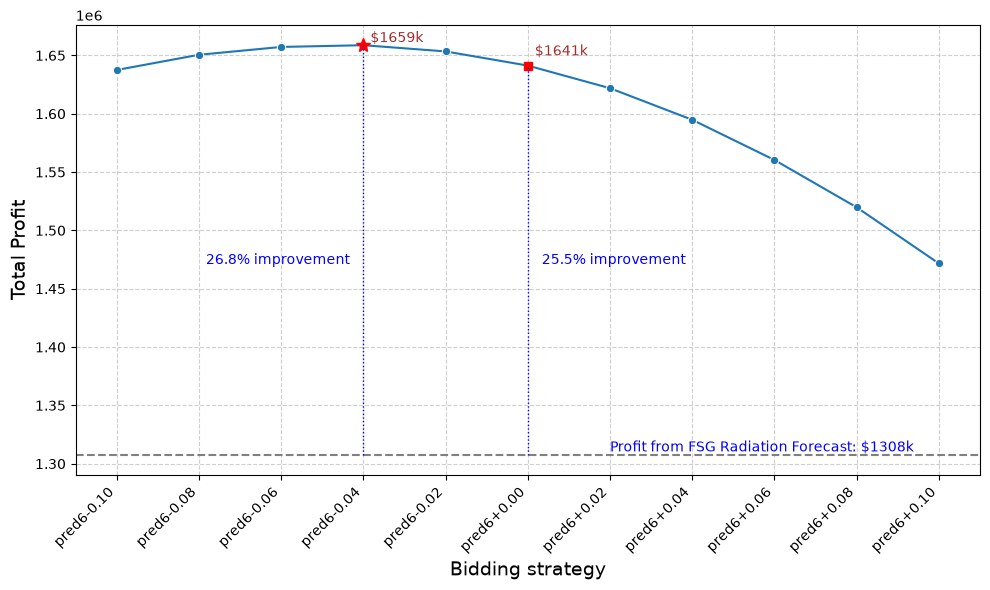

In [46]:
# Filter out 'pred_single' and 'pred0' to 'pred6' models
results_filtered = results[~results['Model'].isin(['pred_single', 'pred0', 'pred1', 'pred2', 'pred3', 'pred4', 'pred5', 'pred6'])].copy()

# Find the row with the maximum total profit
max_profit_row = results_filtered.loc[results_filtered['Total_Profit'].idxmax()]
peak_model = max_profit_row['Model']
peak_profit = max_profit_row['Total_Profit']

plt.figure(figsize=(10, 6))
# Use 'Model' directly as x-axis for lineplot
sns.lineplot(data=results_filtered, x='Model', y='Total_Profit', marker='o')

# Highlight the peak
plt.plot(peak_model, peak_profit, 'r*', markersize=10) # 'ro' for red circle

# Highlight no deviation
pred6_profit = results.loc[results['Model'] == 'pred6', 'Total_Profit'].iloc[0]
plt.plot('pred6+0.00', pred6_profit, 'rs', markersize=6) # 'ro' for red square

# Get the profit for 'pred_single' and add a dashed horizontal line
pred_single_profit = results.loc[results['Model'] == 'pred_single', 'Total_Profit'].iloc[0]
plt.axhline(y=pred_single_profit, color='gray', linestyle='--', label='Pred Single Profit')

# Add a vertical dotted line between the two profit levels
plt.vlines(x='pred6+0.00', ymin=pred_single_profit, ymax=pred6_profit, color='blue', linestyle=':', lw=1)
plt.vlines(x='pred6-0.04', ymin=pred_single_profit, ymax=peak_profit, color='blue', linestyle=':', lw=1)

# Add annotations
plt.annotate(f'${peak_profit/1000:.0f}k',
             xy=(peak_model, peak_profit),
             xytext=(5, 5), # Offset text from the point
             textcoords='offset points',
             ha='left', va='center',
             fontsize=10, color='brown')

plt.annotate(f'${pred6_profit/1000:.0f}k',
             xy=('pred6+0.00', pred6_profit),
             xytext=(5, 5), # Offset text from the point
             textcoords='offset points',
             ha='left', va='bottom',
             fontsize=10, color='brown')

#plt.annotate(f'Further improvement: {(peak_profit/pred6_profit-1)*100:.2f}%',
#             xy=('pred6+0.02', 1.65e6),
#             xytext=(5, 5), # Offset text from the point
#             textcoords='offset points',
#             ha='left', va='bottom',
#             fontsize=13, color='brown')

# Add annotation for improvement from single model to pred6+0.00
plt.annotate(f'{(pred6_profit/pred_single_profit-1)*100:.1f}% improvement',
             xy=('pred6+0.00', (pred_single_profit + pred6_profit) / 2),
             xytext=(10, 0), textcoords='offset points',  # Increased x-offset to move text right
             ha='left', va='center', color='blue', fontsize=10)

# Add annotation for improvement from single model to pred6+0.00
plt.annotate(f'{(peak_profit/pred_single_profit-1)*100:.1f}% improvement',
             xy=('pred6-0.04', (pred_single_profit + pred6_profit) / 2),
             xytext=(-10, 0), textcoords='offset points',  # Increased x-offset to move text right
             ha='right', va='center', color='blue', fontsize=10)

# Add annotation for improvement from single model to pred6+0.00
plt.annotate(f'Profit from FSG Radiation Forecast: ${pred_single_profit/1000:.0f}k',
             xy=('pred6+0.02', pred_single_profit),
             xytext=(0, 0), textcoords='offset points',  # Increased x-offset to move text right
             ha='left', va='bottom', color='blue', fontsize=10)

# plt.title('Total Profit by Model/Deviation')
plt.xlabel('Bidding strategy', fontsize = 14)
plt.ylabel('Total Profit', fontsize = 14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Appendix: What if ... XGBoost?

In [47]:
import xgboost as xgb

# Exclude specific columns
exclude_cols = {'rad_actual', 'gen_actual_kW', 'datetime'}
feature_names = [c for c in df_train.columns if c not in exclude_cols]

# Keep only numeric features (mirrors R's data.matrix behavior)
numeric_train = df_train[feature_names].select_dtypes(include=[np.number])
numeric_test  = df_test[feature_names].select_dtypes(include=[np.number])

# Subset the data frames using consistent column names
X_train = numeric_train[feature_names].to_numpy()
X_test  = numeric_test[feature_names].to_numpy()
y_train = df_train['rad_actual'].to_numpy()
y_test = df_test['rad_actual'].to_numpy()

# DMatrix objects
dtrain = xgb.DMatrix(data=X_train, label=y_train, feature_names=feature_names)
dtest  = xgb.DMatrix(data=X_test,  label=y_test,  feature_names=feature_names)

# Parameters and training
params = {
    "objective": "reg:squarederror"
}

model_xgb = xgb.train(params=params, dtrain=dtrain, num_boost_round=10)

# Predictions
preds_test = model_xgb.predict(dtest)
preds_train = model_xgb.predict(dtrain)

# Metrics: R^2 and RMSE
def r_squared(actual, train, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(train)) ** 2)
    return 1.0 - ss_res / ss_tot

r2_train = r_squared(y_train, y_train, preds_train)
r2_test  = r_squared(y_test, y_train, preds_test)
rmse_val = np.sqrt(np.mean((y_test - preds_test) ** 2))

print(f"R-squared(train): {r2_train:.6f}")
print(f"R-squared(test):  {r2_test:.6f}")
print(f"RMSE:             {rmse_val:.6f}")

R-squared(train): 0.853596
R-squared(test):  0.790966
RMSE:             0.141668


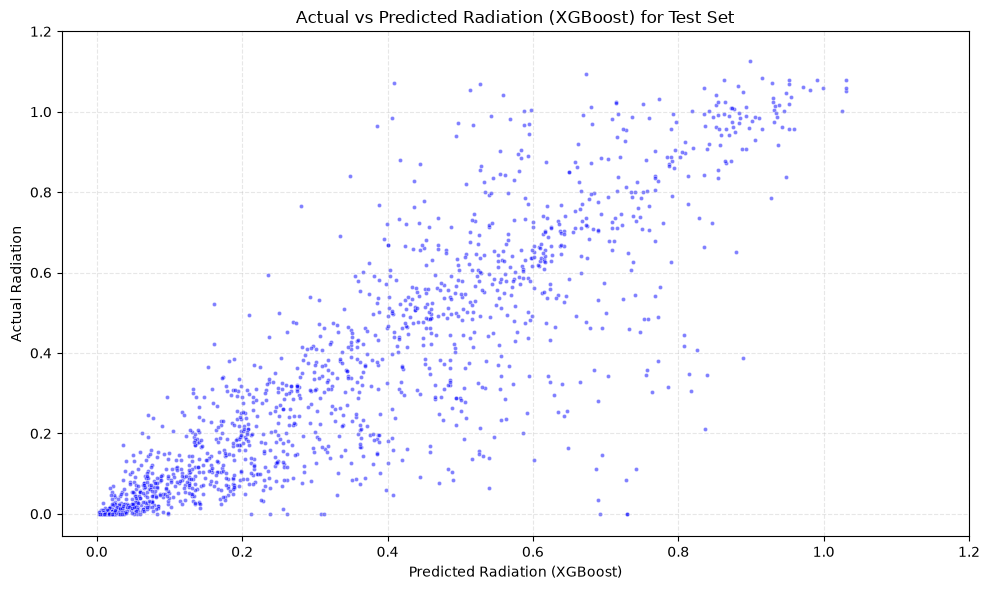

In [48]:
# Scatter plot (actual vs predicted on test set)
plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': preds_test})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='Predicted', y='Actual', color='blue', marker='.', alpha=0.5 )

plt.xlabel('Predicted Radiation (XGBoost)')
plt.ylabel('Actual Radiation')
plt.title('Actual vs Predicted Radiation (XGBoost) for Test Set')

plt.xticks(np.arange(0, 1.21, 0.2))
plt.yticks(np.arange(0, 1.21, 0.2))

# Simple minimal feel
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [49]:
# Feature importance (Gain, Cover, Frequency)
# xgboost's plot_importance shows importance by a chosen type

# xgb.plot_importance uses one type at a time; we’ll build a combined table like R’s xgb.importance:
gain = model_xgb.get_score(importance_type='gain')
cover = model_xgb.get_score(importance_type='cover')
weight = model_xgb.get_score(importance_type='weight')  # frequency

# Put into a DataFrame with all features, filling missing with 0
all_feats = pd.Index(feature_names)
imp_df = pd.DataFrame({
    'Feature': all_feats,
    'Gain':   [gain.get(f, 0.0) for f in all_feats],
    'Cover':  [cover.get(f, 0.0) for f in all_feats],
    'Frequency': [weight.get(f, 0) for f in all_feats]
})

# Normalize Gain/Cover/Frequency to proportions
if imp_df['Gain'].sum() > 0:
    imp_df['Gain'] = imp_df['Gain'] / imp_df['Gain'].sum()
if imp_df['Cover'].sum() > 0:
    imp_df['Cover'] = imp_df['Cover'] / imp_df['Cover'].sum()
if imp_df['Frequency'].sum() > 0:
    imp_df['Frequency'] = imp_df['Frequency'] / imp_df['Frequency'].sum()

# Sort by Gain descending
imp_df = imp_df.sort_values('Gain', ascending=False).reset_index(drop=True)
print(imp_df)

        Feature      Gain     Cover  Frequency
0  rad_forecast  0.509203  0.236120   0.220665
1          hour  0.286544  0.272438   0.147110
2   cloud_cover  0.051573  0.088171   0.059545
3          temp  0.033278  0.096474   0.152364
4         month  0.031958  0.097271   0.064799
5      humidity  0.030901  0.057870   0.152364
6        wind_u  0.028902  0.070428   0.084063
7        wind_v  0.027641  0.081227   0.119089


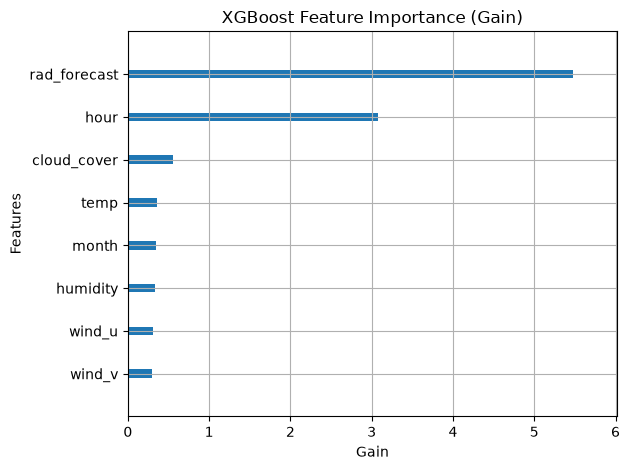

In [50]:
# Plot feature importance
xgb.plot_importance(model_xgb, importance_type='gain', xlabel='Gain', show_values=False)
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()